Saving USD_BRL_hist.csv to USD_BRL_hist (1).csv


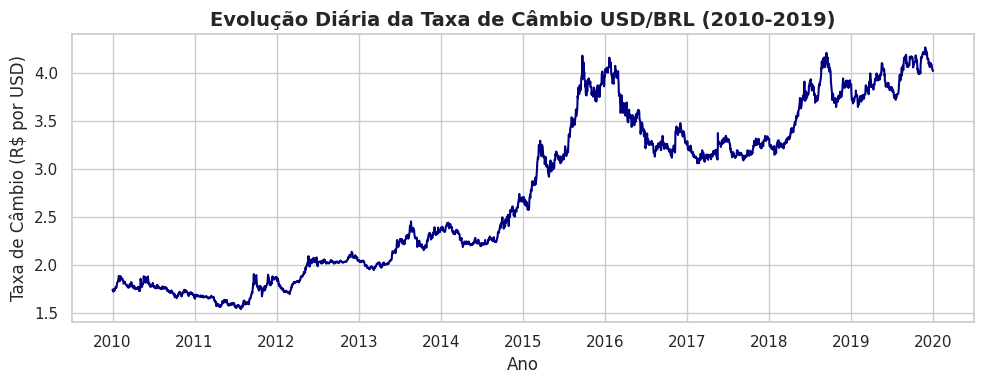

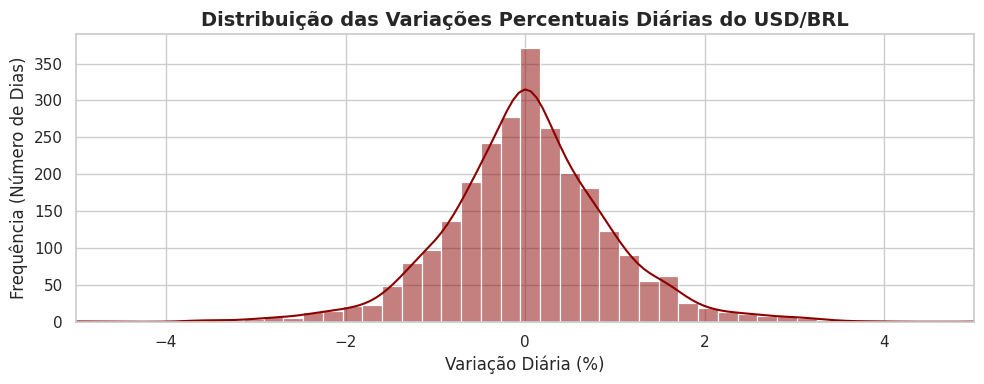

/tmp/ipykernel_683/2347536063.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


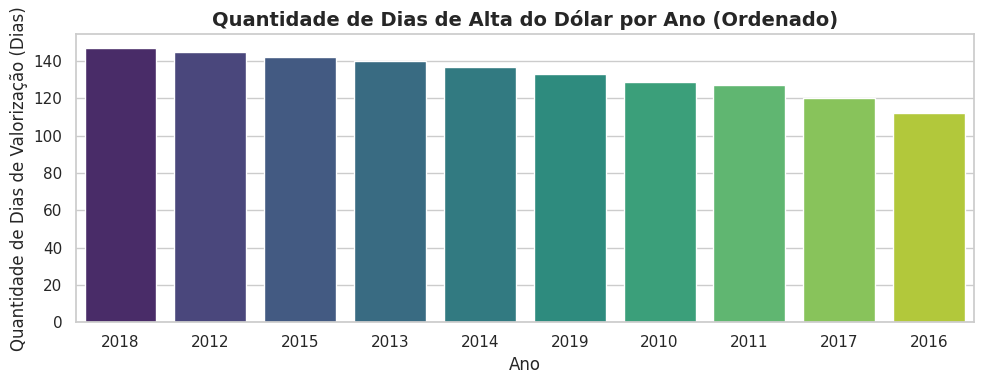

In [6]:

  import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import files

uploaded = files.upload()

# Lendo o arquivo diretamente da memória do upload
nome_arquivo = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nome_arquivo]))


df["Data_parsed"] = pd.to_datetime(df["Data"], format="%d.%m.%Y")

df = df.sort_values("Data_parsed").reset_index(drop=True)

df["Year"] = df["Data_parsed"].dt.year
df["Daily_Return"] = (
    df["USD_BRL"].pct_change() * 100
)  # Variação diária em %
df["Direcao"] = df["Daily_Return"].apply(
    lambda x: "Alta" if x > 0 else ("Baixa" if x < 0 else "Estável")
)

sns.set_theme(style="whitegrid")


fig1, ax1 = plt.subplots(figsize=(10, 4))
sns.lineplot(data=df, x="Data_parsed", y="USD_BRL", color="navy", ax=ax1)
ax1.set_title(
    "Evolução Diária da Taxa de Câmbio USD/BRL (2010-2019)",
    fontsize=14,
    fontweight="bold",
)
ax1.set_xlabel("Ano")
ax1.set_ylabel("Taxa de Câmbio (R$ por USD)")  # UNIDADE 1
fig1.tight_layout()
fig1.savefig("grafico1_cambio.png", dpi=300)
plt.show()


fig2, ax2 = plt.subplots(figsize=(10, 4))
sns.histplot(
    data=df.dropna(),
    x="Daily_Return",
    bins=60,
    color="darkred",
    kde=True,
    ax=ax2,
)
ax2.set_title(
    "Distribuição das Variações Percentuais Diárias do USD/BRL",
    fontsize=14,
    fontweight="bold",
)
ax2.set_xlabel("Variação Diária (%)")  # UNIDADE 2
ax2.set_ylabel("Frequência (Número de Dias)")
ax2.set_xlim(-5, 5)
fig2.tight_layout()
fig2.savefig("grafico2_retornos.png", dpi=300)
plt.show()


df_alta = (
    df[df["Direcao"] == "Alta"].groupby("Year").size().reset_index(name="Dias_Alta")
)
df_alta_sorted = df_alta.sort_values(by="Dias_Alta", ascending=False)

fig3, ax3 = plt.subplots(figsize=(10, 4))
sns.barplot(
    data=df_alta_sorted,
    x="Year",
    y="Dias_Alta",
    palette="viridis",
    order=df_alta_sorted["Year"],
    ax=ax3,
)
ax3.set_title(
    "Quantidade de Dias de Alta do Dólar por Ano (Ordenado)",
    fontsize=14,
    fontweight="bold",
)
ax3.set_xlabel("Ano")
ax3.set_ylabel("Quantidade de Dias de Valorização (Dias)")  # UNIDADE 3
fig3.tight_layout()
fig3.savefig("grafico3_dias_alta.png", dpi=300)
plt.show()
